In [22]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller  # проверка стационарности
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_percentage_error
)

import pmdarima as pm
import statsmodels.api as sm

## Подготовка и анализ

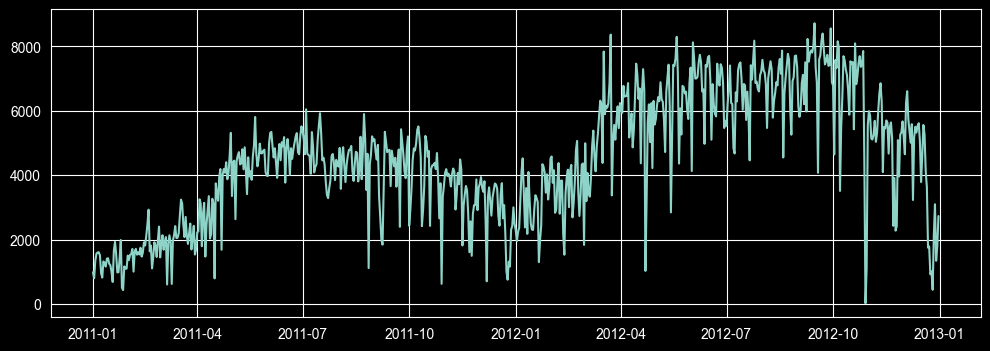

p-value до: 0.3427
p-value после: 0.0000


In [23]:
data = pd.read_csv('../data/day.csv')

data['dteday'] = pd.to_datetime(data['dteday'])  # перевод даты в нужный формат

data.set_index('dteday', inplace=True)  # установка даты в качестве индекса
data = data.asfreq('D')  # задаем дневную частоту

plt.figure(figsize=(12, 4))
plt.plot(data['cnt'])
plt.show()

adf_pvalue = adfuller(data['cnt'].dropna())[1]  # проверка ряда на стационарность
print(f'p-value до: {adf_pvalue:.4f}')

data['cnt_diff'] = data['cnt'].diff()  # первая разность ряда

adf_pvalue_diff = adfuller(data['cnt_diff'].dropna())[1]  # повторная проверка
print(f'p-value после: {adf_pvalue_diff:.4f}')

## Базовая ARIMA-модель

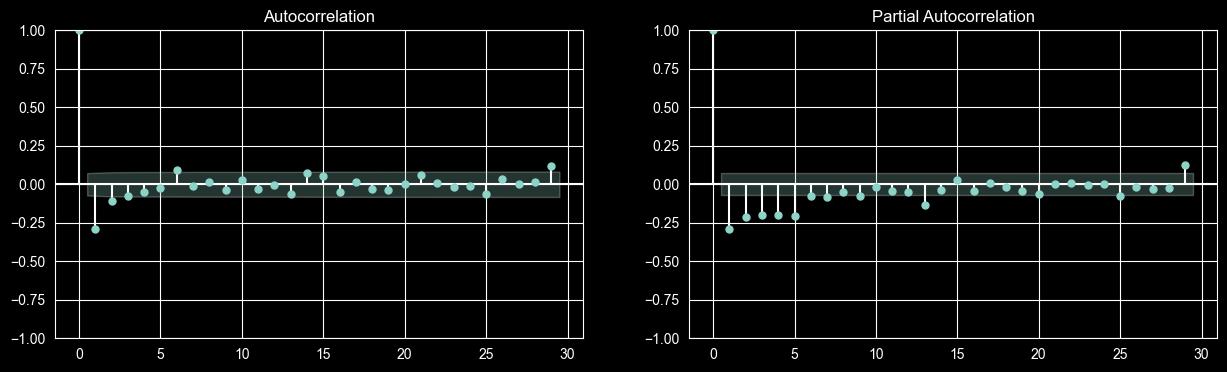

ARIMA RMSE: 2936.07, MAPE: 5.35


In [24]:
fig, chart_axes = plt.subplots(1, 2, figsize=(15, 4))

plot_acf(data['cnt_diff'].dropna(), ax=chart_axes[0])  # график для оценки q
plot_pacf(data['cnt_diff'].dropna(), ax=chart_axes[1])  # график для оценки p
plt.show()

split_index = int(len(data) * 0.9)  # 90% данных на обучение

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]  # разделение выборки

arima_model = ARIMA(train_data['cnt'], order=(1, 1, 1))  # модель ARIMA
arima_result = arima_model.fit()  # обучение модели

forecast_values = arima_result.forecast(steps=len(test_data))  # прогноз

rmse_value = root_mean_squared_error(test_data['cnt'], forecast_values)  # RMSE
mape_value = mean_absolute_percentage_error(test_data['cnt'], forecast_values)  # MAPE

print(f'ARIMA RMSE: {rmse_value:.2f}, MAPE: {mape_value:.2f}')

## Диагностика модели

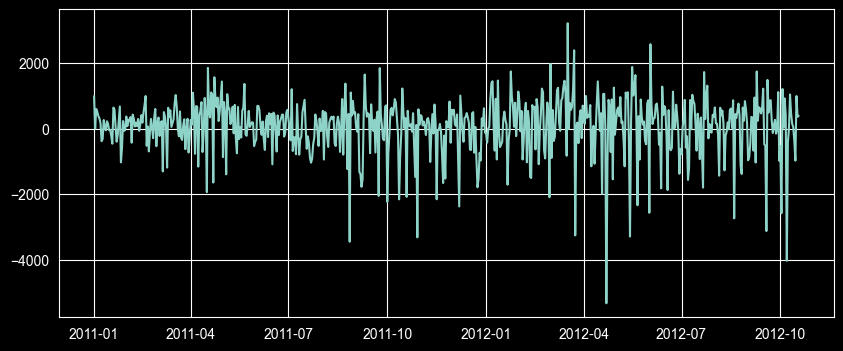

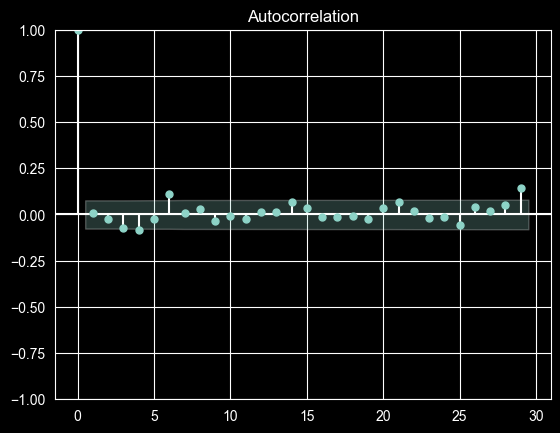

      lb_stat  lb_pvalue
10  18.441833   0.047952


In [25]:
model_residuals = arima_result.resid  # остатки обученной модели

plt.figure(figsize=(10, 4))
plt.plot(model_residuals)  # визуализация остатков
plt.show()

plot_acf(model_residuals.dropna())  # проверка автокорреляции остатков
plt.show()

ljung_box_result = sm.stats.acorr_ljungbox(
    model_residuals.dropna(),
    lags=[10]
)  # тест Льюнга-Бокса

print(ljung_box_result)  # p-value > 0.05 означает отсутствие зависимостей

## Сезонная модель SARIMA

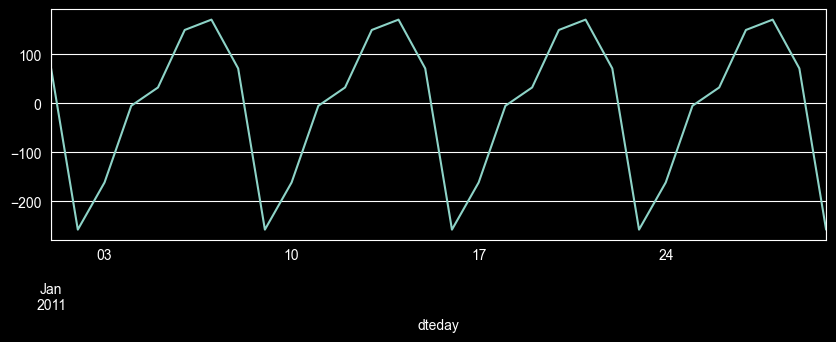

SARIMA MAPE: 5.27


In [26]:
seasonal_parts = seasonal_decompose(
    data['cnt'].dropna(),
    period=7
)  # выделение недельной сезонности

seasonal_parts.seasonal[:30].plot(figsize=(10, 3))  # отображение сезонной компоненты
plt.show()

sarima_model = SARIMAX(
    train_data['cnt'],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7)
)  # модель с недельной сезонностью

sarima_result = sarima_model.fit(disp=False)  # обучение модели

sarima_forecast = sarima_result.forecast(
    steps=len(test_data)
)  # прогноз на тестовой выборке

sarima_mape = mean_absolute_percentage_error(
    test_data['cnt'],
    sarima_forecast
)  # расчет MAPE

print(f'SARIMA MAPE: {sarima_mape:.2f}')

## SARIMAX и внешние факторы (Погода)

In [27]:
weather_train = train_data[['temp']]  # температура для обучения
weather_test = test_data[['temp']]  # температура для теста

sarimax_model = SARIMAX(
    train_data['cnt'],
    exog=weather_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7)
)  # модель с внешним фактором

sarimax_result = sarimax_model.fit(disp=False)  # обучение модели

sarimax_forecast = sarimax_result.forecast(
    steps=len(test_data),
    exog=weather_test
)  # прогноз с учетом температуры

sarimax_mape = mean_absolute_percentage_error(
    test_data['cnt'],
    sarimax_forecast
)  # расчет MAPE

print(f'SARIMAX MAPE: {sarimax_mape:.2f}')

print(
    sarimax_result.summary().tables[1]
)  # проверка значимости признака temp

SARIMAX MAPE: 4.88
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        4644.8228    485.601      9.565      0.000    3693.062    5596.584
ar.L1          0.3064      0.039      7.876      0.000       0.230       0.383
ma.L1         -0.9217      0.017    -54.352      0.000      -0.955      -0.888
ar.S.L7        0.9993      0.080     12.450      0.000       0.842       1.157
ma.S.L7       -0.9983      0.121     -8.256      0.000      -1.235      -0.761
sigma2      7.043e+05      0.621   1.13e+06      0.000    7.04e+05    7.04e+05


## Автоматизация подбора (auto-ARIMA)

In [28]:
auto_arima_model = pm.auto_arima(
    train_data['cnt'],
    X=weather_train,
    seasonal=True,
    m=7,
    trace=True
)  # автоматический подбор параметров модели

print(auto_arima_model.summary())  # вывод найденной конфигурации

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=10700.180, Time=0.91 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=10920.608, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=10849.716, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=10744.981, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=10918.670, Time=0.07 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=0.75 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=10702.179, Time=1.38 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=10702.197, Time=1.50 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=inf, Time=1.30 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=10705.279, Time=1.63 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=10699.600, Time=0.83 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=10697.4

# Ответы на вопросы

### 1. Алгоритм может показывать низкую точность при появлении нестандартных событий, которые отсутствовали в обучающей выборке, например во время экономических потрясений, пандемий или других резких изменений. Кроме того, ему бывает сложно корректно учитывать несколько сезонных циклов одновременно, например недельный и годовой. В таких ситуациях отдельные выбросы могут ошибочно восприниматься как устойчивые закономерности, что приводит к неудачному выбору параметров модели.

### 2. Одним из распространённых недостатков является склонность к выбору слишком большого порядка дифференцирования (d и D). Стремясь добиться стационарности ряда, алгоритм иногда выполняет лишние преобразования. В результате часть информации о долгосрочных тенденциях теряется, что может негативно сказаться на качестве прогноза.

### 3. Несмотря на автоматизацию процесса подбора параметров, результаты работы модели требуют контроля со стороны специалиста. Характер данных со временем меняется, поэтому оптимальные настройки также могут изменяться. Если использовать auto-ARIMA без мониторинга качества прогнозов, существует риск ухудшения точности модели. По этой причине на практике обычно отслеживают метрики ошибок и периодически пересматривают параметры модели.